# Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.cluster import KMeans

# Business Problem Understanding

Customer Lifetime Value (CLV) represents the total value a customer is expected to generate for a business over time.

Increasing customer lifetime value is important because long-term customers often generate more revenue and are more cost-effective than acquiring new customers.

Unlike one-time sales, CLV focuses on long-term customer relationships and future revenue potential.

Targeting existing customers is usually more efficient because:
- Customer acquisition costs are high
- Existing customers already trust the business
- Loyal customers are more likely to make repeat purchases

The objective of this project is to analyze customer behavior, segment customers based on value, and predict future customer spending using regression models.

Future spending prediction helps businesses:
- Identify high-value customers
- Improve upselling opportunities
- Design personalized offers
- Increase long-term revenue
- Optimize customer retention strategies

# Load Dataset

In [2]:
df = pd.read_csv("data/clv_data.csv")

df.head()

,CustomerID,Age,AnnualIncome,WebsiteVisits,AppSessions,PreviousOrders,AverageOrderValue,DaysSinceLastPurchase,ReturnRate,CancellationRate,LoyaltyTier,DiscountUsedLastCampaign,Year1Spending,FutureSpending
0,LTV00001,33,64196.02,145,61,19,1403.79,242,0.136,0.028,Gold,No,25356.80,12438.46
1,LTV00002,46,69889.53,153,111,2,988.47,223,0.126,0.067,Silver,Yes,2768.68,5860.22
2,LTV00003,20,83269.51,175,112,34,2386.24,101,0.026,0.087,Silver,No,80895.63,39203.34
3,LTV00004,44,79914.63,22,80,0,1121.87,98,0.037,0.004,Gold,Yes,874.95,3157.73
4,LTV00005,26,84091.39,24,166,12,1942.48,256,0.052,0.004,Gold,No,22962.40,11423.53


# Data Understanding

The dataset contains customer demographic, engagement, purchasing, and spending information used to analyze customer lifetime value and predict future spending.

## Important Columns

- CustomerID → Unique customer identifier
- Age → Customer age
- AnnualIncome → Annual customer income
- WebsiteVisits → Number of website visits
- AppSessions → Number of mobile app sessions
- PreviousOrders → Number of previous orders
- AverageOrderValue → Average value of customer orders
- DaysSinceLastPurchase → Recency of customer activity
- ReturnRate → Percentage of returned orders
- CancellationRate → Percentage of cancelled orders
- LoyaltyTier → Customer loyalty category
- DiscountUsedLastCampaign → Whether customer used discounts previously
- Year1Spending → Previous customer spending
- FutureSpending → Future spending amount (target variable)

## Customer Behavior Columns
- WebsiteVisits
- AppSessions
- PreviousOrders
- DaysSinceLastPurchase
- ReturnRate
- CancellationRate

## Customer Value Columns
- AverageOrderValue
- Year1Spending
- FutureSpending
- LoyaltyTier

## Target Variable
- FutureSpending

This is a regression problem because the target variable contains continuous numerical values.

# Data Cleaning and Feature Engineering

In [3]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (1400, 14)

Missing Values:

CustomerID                   0
Age                          0
AnnualIncome                 9
WebsiteVisits                0
AppSessions                  0
PreviousOrders               0
AverageOrderValue           10
DaysSinceLastPurchase        0
ReturnRate                   0
CancellationRate             0
LoyaltyTier                  0
DiscountUsedLastCampaign     0
Year1Spending                0
FutureSpending               0
dtype: int64

Duplicate Records: 0

Data Types:

CustomerID                   object
Age                           int64
AnnualIncome                float64
WebsiteVisits                 int64
AppSessions                   int64
PreviousOrders                int64
AverageOrderValue           float64
DaysSinceLastPurchase         int64
ReturnRate                  float64
CancellationRate            float64
LoyaltyTier                  object
DiscountUsedLastCampaign     object
Year1Spending               float64
Futur

In [4]:
df['AnnualIncome'] = df['AnnualIncome'].fillna(
    df['AnnualIncome'].median()
)

df['AverageOrderValue'] = df['AverageOrderValue'].fillna(
    df['AverageOrderValue'].median()
)

df['EngagementScore'] = (
    df['WebsiteVisits'] + df['AppSessions']
)

df['SpendingPerOrder'] = (
    df['Year1Spending'] / (df['PreviousOrders'] + 1)
)

print(df.isnull().sum())

CustomerID                  0
Age                         0
AnnualIncome                0
WebsiteVisits               0
AppSessions                 0
PreviousOrders              0
AverageOrderValue           0
DaysSinceLastPurchase       0
ReturnRate                  0
CancellationRate            0
LoyaltyTier                 0
DiscountUsedLastCampaign    0
Year1Spending               0
FutureSpending              0
EngagementScore             0
SpendingPerOrder            0
dtype: int64


### Feature Engineering Summary

- EngagementScore:
  Measures customer activity across website visits and app sessions.

- SpendingPerOrder:
  Represents average historical spending efficiency per order.

These features help improve customer behavior understanding and future spending prediction.

# Outlier Analysis

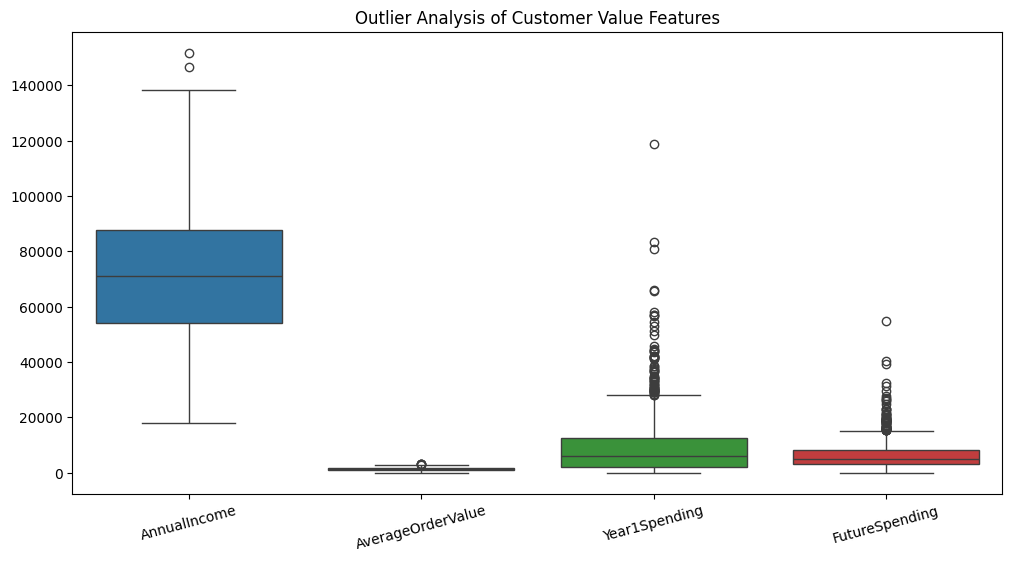

In [5]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[[
    'AnnualIncome',
    'AverageOrderValue',
    'Year1Spending',
    'FutureSpending'
]])

plt.title('Outlier Analysis of Customer Value Features')

plt.xticks(rotation=15)

plt.show()

### Interpretation
Some outliers are visible in customer spending and income-related features. These may represent premium or high-value customers and can provide important business insights.

# Exploratory Data Analysis

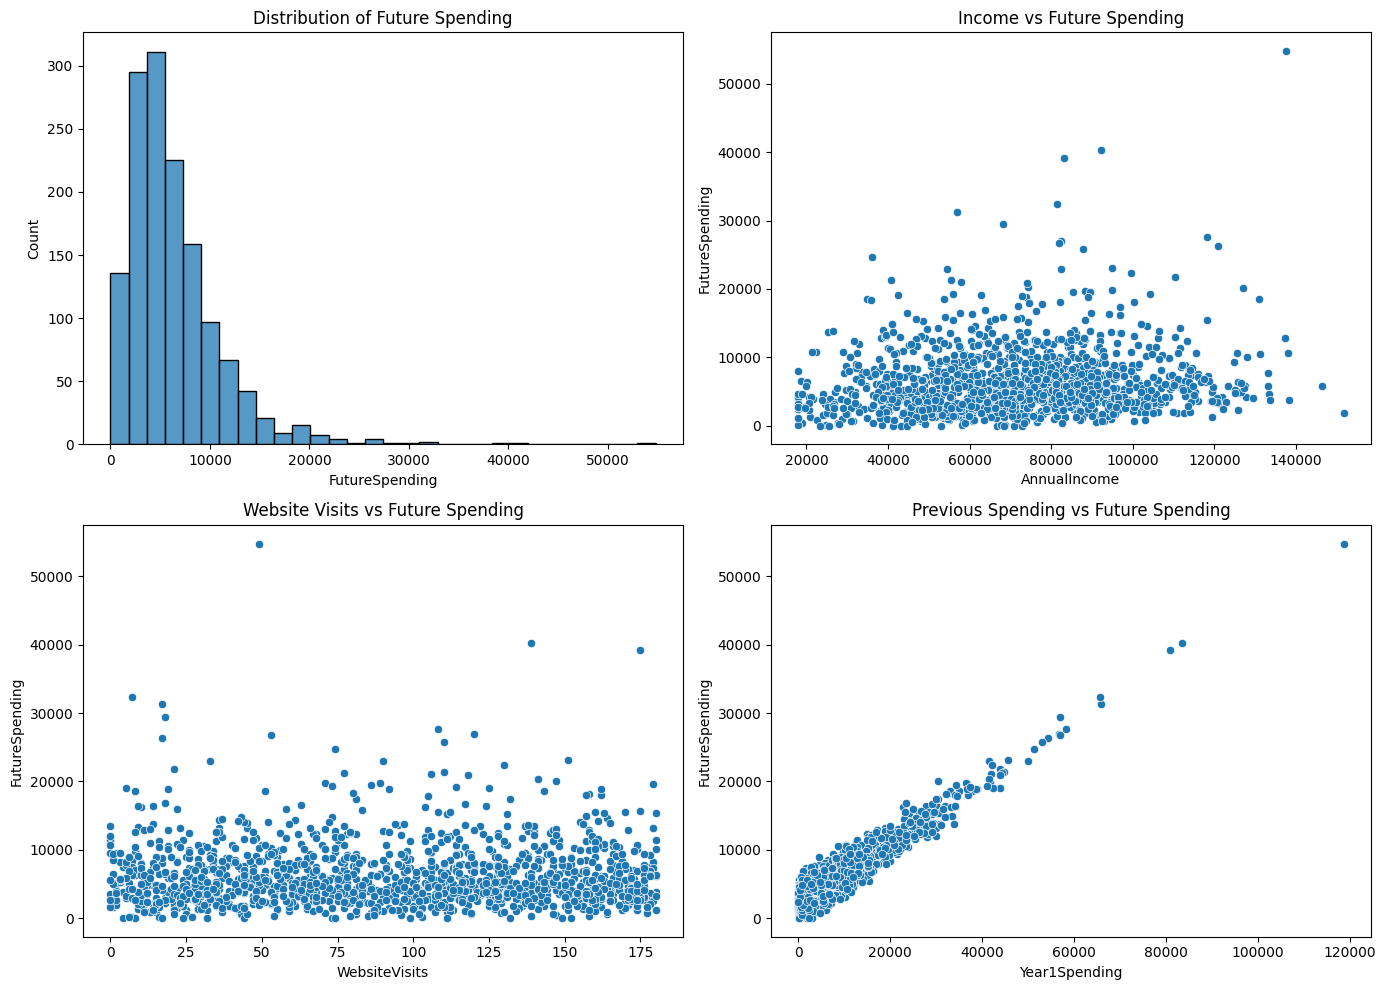

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.histplot(df['FutureSpending'], bins=30, ax=axes[0,0])
axes[0,0].set_title('Distribution of Future Spending')

sns.scatterplot(
    x=df['AnnualIncome'],
    y=df['FutureSpending'],
    ax=axes[0,1]
)
axes[0,1].set_title('Income vs Future Spending')

sns.scatterplot(
    x=df['WebsiteVisits'],
    y=df['FutureSpending'],
    ax=axes[1,0]
)
axes[1,0].set_title('Website Visits vs Future Spending')

sns.scatterplot(
    x=df['Year1Spending'],
    y=df['FutureSpending'],
    ax=axes[1,1]
)
axes[1,1].set_title('Previous Spending vs Future Spending')

plt.tight_layout()
plt.show()

### Interpretation
Customers with higher previous spending generally show higher future spending potential. Website engagement and annual income also appear to influence customer value and future purchasing behavior.

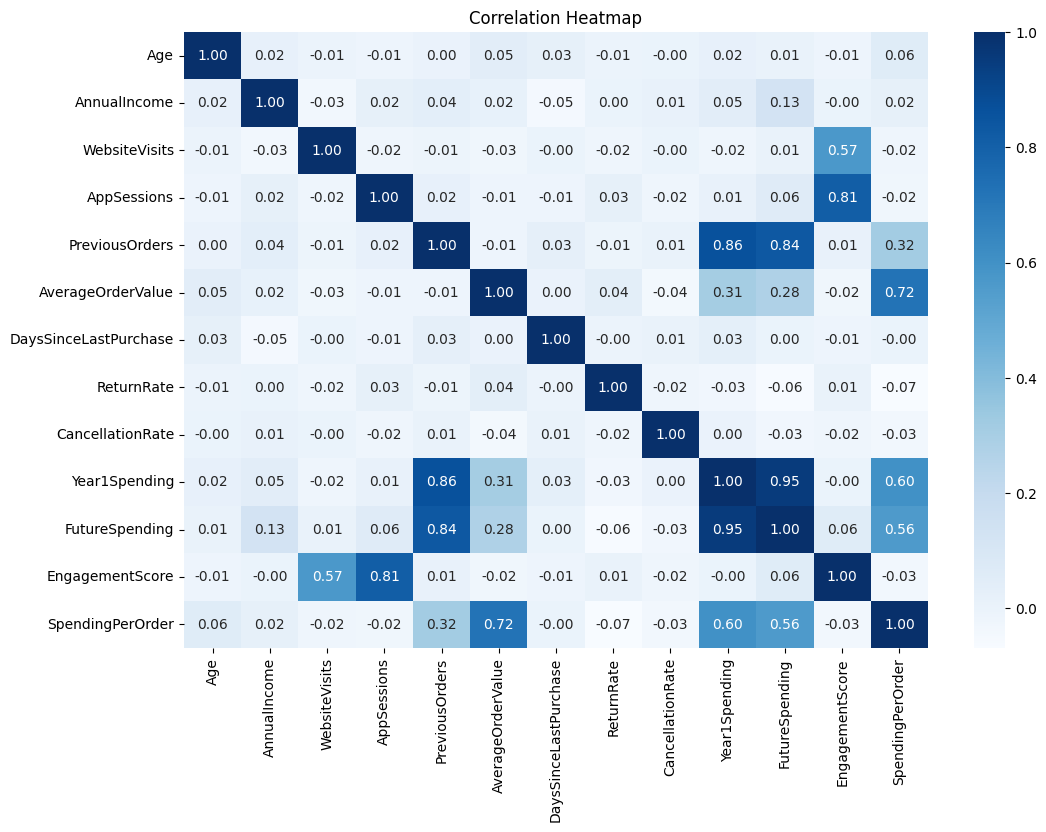

In [7]:
plt.figure(figsize=(12,8))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

### Interpretation
Previous spending, average order value, and engagement-related features show positive relationships with future spending. Strong correlations may indicate important predictors for customer lifetime value analysis.

# Customer Segmentation

In [8]:
segmentation_features = df[[
    'Year1Spending',
    'FutureSpending',
    'EngagementScore'
]]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(segmentation_features)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['CustomerSegment'] = kmeans.fit_predict(
    scaled_features
)

df[['CustomerSegment',
    'Year1Spending',
    'FutureSpending']].head()

,CustomerSegment,Year1Spending,FutureSpending
0,2,25356.80,12438.46
1,0,2768.68,5860.22
2,2,80895.63,39203.34
3,1,874.95,3157.73
4,2,22962.40,11423.53


In [9]:
segment_summary = df.groupby('CustomerSegment')[[
    'Year1Spending',
    'FutureSpending',
    'EngagementScore'
]].mean()

segment_summary

,Year1Spending,FutureSpending,EngagementScore
CustomerSegment,,,
0,5266.663323,4830.929258,294.062903
1,6265.790961,4753.654555,140.967972
2,27530.630367,14548.811330,233.371560


### Segmentation Interpretation

- Segment 0:
  Medium-value customers with moderate engagement and spending.

- Segment 1:
  High-value customers with high previous and future spending.

- Segment 2:
  Lower-value or low-engagement customers with lower spending behavior.

# Future Spending Prediction

In [10]:
df = pd.get_dummies(
    df,
    columns=['LoyaltyTier', 'DiscountUsedLastCampaign'],
    drop_first=True
)

X = df.drop([
    'CustomerID',
    'FutureSpending',
    'CustomerSegment'
], axis=1)

y = df['FutureSpending']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()

tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

linear_model.fit(X_train, y_train)

tree_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

tree_pred = tree_model.predict(X_test)

print("Models trained successfully.")

Models trained successfully.


# Model Evaluation

In [11]:
models = {
    'Linear Regression': linear_pred,
    'Decision Tree': tree_pred
}

for name, pred in models.items():

    mae = mean_absolute_error(y_test, pred)

    mse = mean_squared_error(y_test, pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, pred)

    print(f"\n{name}")
    print("-" * 30)

    print("MAE :", round(mae, 2))
    print("MSE :", round(mse, 2))
    print("RMSE:", round(rmse, 2))
    print("R2 Score:", round(r2, 2))


Linear Regression
------------------------------
MAE : 956.26
MSE : 1489919.42
RMSE: 1220.62
R2 Score: 0.93

Decision Tree
------------------------------
MAE : 1226.81
MSE : 2353876.94
RMSE: 1534.23
R2 Score: 0.89


### Model Performance Interpretation

## Linear Regression
- Achieved an R² score of 0.93
- Predicted future spending with lower error values
- Performed better overall for future spending prediction

## Decision Tree Regressor
- Achieved an R² score of 0.89
- Produced higher prediction errors compared to Linear Regression

## Business Interpretation

The Linear Regression model explains approximately 93% of the variation in future customer spending, indicating strong predictive performance.

Previous customer spending, order behavior, and engagement metrics appear to be strong predictors of future customer value.

The model can help businesses:
- Identify high-value customers
- Predict future revenue
- Improve personalized marketing
- Optimize retention strategies

# Business Recommendations

- Provide premium offers and loyalty rewards to high-value customers in Segment 2.
- Use personalized upselling campaigns for medium-value customers to increase spending.
- Re-engage low-engagement customers using discounts and targeted marketing campaigns.
- Avoid spending excessive marketing budgets on customers with low engagement and low future spending potential.
- Focus retention strategies on customers with strong historical spending behavior.
- Increase customer engagement through app notifications, personalized recommendations, and loyalty programs.
- Encourage repeat purchases using membership benefits and exclusive offers.
- Monitor cancellation and return rates to reduce revenue leakage.

# Conclusion

This project analyzed customer behavior, customer lifetime value, and future spending patterns using data analytics and machine learning techniques.

Customer segmentation identified high-value, medium-value, and low-engagement customer groups. Regression models were used to predict future customer spending, with Linear Regression achieving the best performance.

The analysis showed that previous spending, engagement behavior, and order patterns are strong indicators of future customer value.

These insights can help businesses improve customer retention, optimize marketing strategies, and increase long-term revenue growth.

In [12]:
segment_summary.to_csv(
    "outputs/customer_segments.csv"
)

model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'MAE': [956.26, 1226.81],
    'RMSE': [1220.62, 1534.23],
    'R2 Score': [0.93, 0.89]
})

model_results.to_csv(
    "outputs/model_results.csv",
    index=False
)